# Proyecto 2 — Competencia de Agentes en Space Invaders (Dueling Double DQN)

**Curso:** CC3092 - Deep Learning y Sistemas Inteligentes

Este notebook demuestra el pipeline completo del proyecto:

1. Preprocesamiento del entorno (`wrappers.py`).
2. Arquitectura Dueling DQN (`model.py`).
3. Agente Double DQN (`agent.py`) y replay buffer (`replay_buffer.py`).
4. Una corrida corta de entrenamiento ("smoke test") para verificar que
   todo el pipeline funciona de extremo a extremo.
5. Gráficas de las curvas de entrenamiento (recompensa y pérdida).
6. Evaluación del checkpoint resultante con política greedy y generación
   de video.

> **Importante:** la corrida de este notebook es intencionalmente corta
> (unos pocos miles de pasos) para poder ejecutarse rápidamente como
> prueba de humo. El agente **no** alcanza buen desempeño con tan pocos
> pasos — para el entrenamiento real, usar `src/train.py` desde la línea
> de comandos con `--total-steps` del orden de 1-2 millones sobre GPU
> (laptop propia o Google Colab), según se explica en el `README.md`.


## 1. Instalación de dependencias

In [1]:
# !pip install -r ../requirements.txt


## 2. Imports y verificación del entorno

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from wrappers import build_train_env, build_eval_env
from model import DuelingDQN
from agent import DQNAgent
from replay_buffer import ReplayBuffer

print("Torch:", torch.__version__, "| CUDA disponible:", torch.cuda.is_available())


Torch: 2.14.0+cu126 | CUDA disponible: True


## 3. Preprocesamiento del entorno

`build_train_env` aplica `AtariPreprocessing` (escala de grises,
redimensionamiento a 84x84, frame skipping con max-pooling) y
`FrameStackObservation` (apila 4 frames), además de recorte de recompensa
(`ClipRewardWrapper`) solo para entrenamiento.

Forma de la observación: (4, 84, 84) uint8
Espacio de acción: Discrete(6)
Significado de las acciones: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


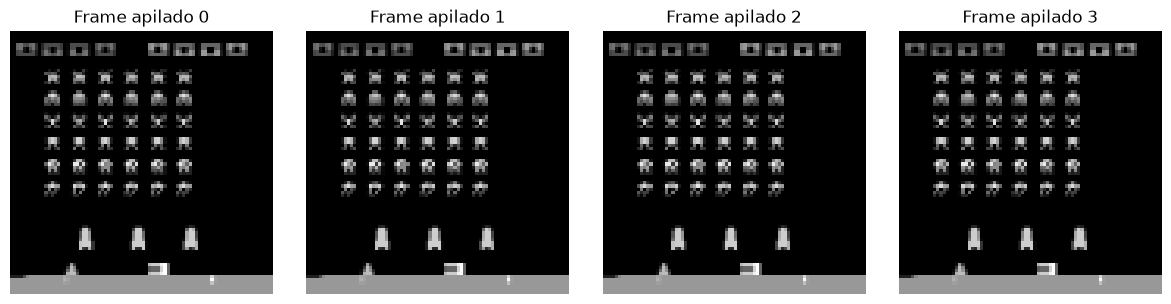

In [3]:
env = build_train_env()
obs, info = env.reset()
print("Forma de la observación:", obs.shape, obs.dtype)
print("Espacio de acción:", env.action_space)
print("Significado de las acciones:", env.unwrapped.get_action_meanings())

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(np.array(obs)[i], cmap="gray")
    axes[i].set_title(f"Frame apilado {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()
env.close()


## 4. Arquitectura Dueling DQN

In [4]:
net = DuelingDQN(in_channels=4, n_actions=6)
n_params = sum(p.numel() for p in net.parameters())
print("Número de parámetros:", n_params)
print(net)


Número de parámetros: 2213031
DuelingDQN(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
  (fc_tronco): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU(inplace=True)
  )
  (value_stream): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=1, bias=True)
  )
  (advantage_stream): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)


## 5. Corrida corta de entrenamiento (smoke test)

Se entrena por unos pocos miles de pasos, con un buffer y un
`learning_starts` pequeños, únicamente para validar que todo el pipeline
(selección de acción, almacenamiento en el buffer, cálculo de la pérdida
Double DQN, actualización de la red target y guardado de checkpoints)
funciona correctamente.

In [5]:
import sys
import subprocess

resultado = subprocess.run(
    [
        sys.executable, "train.py",
        "--run-name", "demo_notebook",
        "--total-steps", "6000",
        "--buffer-size", "6000",
        "--learning-starts", "500",
        "--target-update-freq", "500",
        "--checkpoint-freq", "6000",
        "--eps-decay-steps", "5000",
        "--eps-end", "0.1",
        "--log-dir", "../logs",
        "--checkpoint-dir", "../checkpoints",
    ],
    cwd="../src",
    capture_output=True,
    text=True,
)
print(resultado.stdout[-3000:])
if resultado.returncode != 0:
    print("STDERR:", resultado.stderr[-3000:])


Dispositivo de entrenamiento: cuda
[step 165] episodio 0 | recompensa=5.0 | pasos=165 | epsilon=0.970 | loss=nan | t=0s
[step 366] episodio 1 | recompensa=4.0 | pasos=201 | epsilon=0.934 | loss=nan | t=0s
[step 519] episodio 2 | recompensa=1.0 | pasos=153 | epsilon=0.907 | loss=0.0169 | t=1s
[step 691] episodio 3 | recompensa=2.0 | pasos=172 | epsilon=0.876 | loss=0.0089 | t=1s
[step 793] episodio 4 | recompensa=0.0 | pasos=102 | epsilon=0.857 | loss=0.0094 | t=1s
[step 1279] episodio 5 | recompensa=16.0 | pasos=486 | epsilon=0.770 | loss=0.0101 | t=2s
[step 1374] episodio 6 | recompensa=0.0 | pasos=95 | epsilon=0.753 | loss=0.0120 | t=2s
[step 1505] episodio 7 | recompensa=2.0 | pasos=131 | epsilon=0.729 | loss=0.0093 | t=3s
[step 1705] episodio 8 | recompensa=4.0 | pasos=200 | epsilon=0.693 | loss=0.0074 | t=3s
[step 1995] episodio 9 | recompensa=7.0 | pasos=290 | epsilon=0.641 | loss=0.0105 | t=4s
[step 2212] episodio 10 | recompensa=5.0 | pasos=217 | epsilon=0.602 | loss=0.0110 | t

## 6. Curvas de entrenamiento (recompensa y pérdida)

In [6]:
log = pd.read_csv("../logs/demo_notebook.csv")
log.head()


,step,episode,episode_reward,episode_length,epsilon,avg_loss_last_train,elapsed_seconds
0,165,0,5.0,165,0.9703,NaN,0.2
1,366,1,4.0,201,0.9341,NaN,0.4
2,519,2,1.0,153,0.9066,0.016871,0.6
3,691,3,2.0,172,0.8756,0.008945,1.0
4,793,4,0.0,102,0.8573,0.009382,1.2


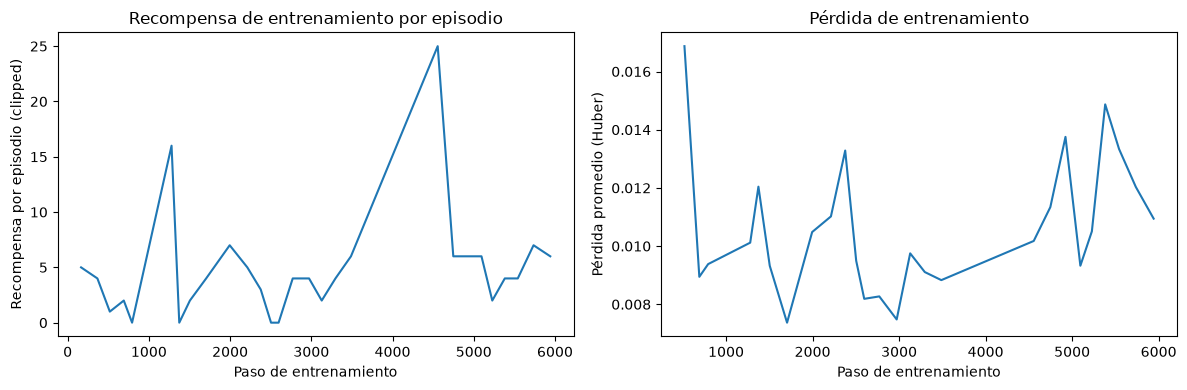

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log["step"], log["episode_reward"])
axes[0].set_xlabel("Paso de entrenamiento")
axes[0].set_ylabel("Recompensa por episodio (clipped)")
axes[0].set_title("Recompensa de entrenamiento por episodio")

axes[1].plot(log["step"], log["avg_loss_last_train"])
axes[1].set_xlabel("Paso de entrenamiento")
axes[1].set_ylabel("Pérdida promedio (Huber)")
axes[1].set_title("Pérdida de entrenamiento")

plt.tight_layout()
plt.show()


> Con solo 6,000 pasos no se espera ver una tendencia clara de mejora —
> esto es solo una prueba de que el pipeline de logging y entrenamiento
> funciona. En el entrenamiento real (millones de pasos, ver README), estas
> mismas gráficas —generadas a partir del mismo `logs/<run_name>.csv`— son
> las que se deben incluir en la sección 2.3 del reporte escrito, idealmente
> aplicando un promedio móvil (rolling mean) para suavizar el ruido episodio
> a episodio.

## 7. Evaluación del checkpoint con política greedy y generación de video

Se reutiliza el mismo patrón `ejecutar_episodio` / cierre del entorno del
Laboratorio #5, ahora con la política aprendida (`agent.act_greedy`) en vez
del agente aleatorio o de regla simple, y usando el entorno de evaluación
(sin reward clipping, con las 3 vidas completas).

In [8]:
sys.path.insert(0, "../src")
from evaluate import ejecutar_episodio_evaluacion

env_eval = build_eval_env(
    video_folder="../videos/demo_notebook_eval",
    name_prefix="space_invaders_dqn_demo",
    episode_trigger=lambda ep: True,
)

agent = DQNAgent(n_actions=env_eval.action_space.n)
agent.load("../checkpoints/demo_notebook_final.pt")

recompensas = []
try:
    for ep in range(2):
        resultado = ejecutar_episodio_evaluacion(env_eval, agent, max_steps=3000)
        recompensas.append(resultado["recompensa_total"])
        print(f"Episodio {ep}: pasos={resultado['pasos']}, "
              f"recompensa_total={resultado['recompensa_total']}")
finally:
    env_eval.close()

print()
print("Recompensa promedio:", np.mean(recompensas))
print("Recompensa máxima:", np.max(recompensas))


c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Deep\proyecto2_deepLearning\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Deep\proyecto2_deepLearning\videos\demo_notebook_eval folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episodio 0: pasos=943, recompensa_total=340.0
Episodio 1: pasos=715, recompensa_total=175.0

Recompensa promedio: 257.5
Recompensa máxima: 340.0


In [9]:
from IPython.display import Video
import os

videos = sorted([
    os.path.join("../videos/demo_notebook_eval", f)
    for f in os.listdir("../videos/demo_notebook_eval")
    if f.endswith(".mp4")
])
print(videos)
Video(videos[0], embed=True, width=480)


['../videos/demo_notebook_eval\\space_invaders_dqn_demo-episode-0.mp4', '../videos/demo_notebook_eval\\space_invaders_dqn_demo-episode-1.mp4']


## 8. Próximos pasos

1. Lanzar el entrenamiento real con `src/train.py` en GPU (laptop propia o
   Google Colab) por al menos 1-2 millones de pasos.
2. Repetir este análisis de curvas (sección 6) con los logs de esa corrida
   real, y documentar cada iteración de hiperparámetros en la tabla de la
   plantilla de reporte (`report/plantilla_reporte.md`).
3. Ejecutar `src/evaluate.py` con el checkpoint final para obtener las
   métricas y el video que se usarán el día de la presentación.

<Axes: title={'center': 'Recompensa promedio (rolling 50 episodios)'}, xlabel='step'>

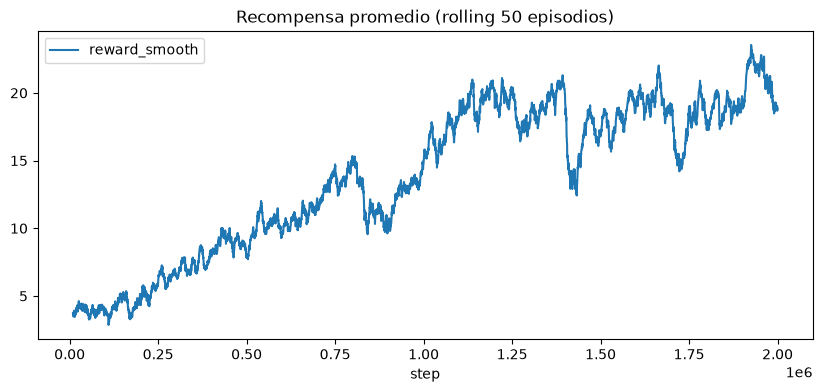

In [28]:
import pandas as pd
log = pd.read_csv("../logs/corrida01.csv")
log["reward_smooth"] = log["episode_reward"].rolling(50).mean()
log.plot(x="step", y="reward_smooth", figsize=(10,4), title="Recompensa promedio (rolling 50 episodios)")